## ⚙️ Step 1 — Cài đặt & Import

In [ ]:
!pip install segmentation-models-pytorch torch torchvision nibabel tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.7 MB/s eta 0:00:00


In [ ]:
import os, json, random, time, csv
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Import xong!")
print(f"   Device : {DEVICE}")
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {vram_gb:.1f} GB")
print(f"   PyTorch: {torch.__version__}")
print(f"   SMP    : {smp.__version__}")

✅ Import xong!
   Device : cuda
   GPU    : Tesla T4
   VRAM   : 14.6 GB
   PyTorch: 2.10.0+cu128
   SMP    : 0.5.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
# ============================================================
# Cấu hình đường dẫn & Hyperparameters
# ============================================================
DRIVE_ROOT     = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
IMAGES_2D_DIR  = f"{DRIVE_ROOT}/data/processed/images"
MASKS_2D_DIR   = f"{DRIVE_ROOT}/data/processed/masks"
METADATA_PATH  = f"{DRIVE_ROOT}/data/processed/metadata.json"

# ✅ THƯ MỤC RIÊNG cho Baseline — không ghi đè checkpoint CIL
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints_baseline"
LOG_DIR        = f"{DRIVE_ROOT}/logs_baseline"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IGNORE_INDEX = 255  # Giữ nguyên để tương thích — nhưng baseline KHÔNG dùng

TRAIN_CFG = {
    "batch_size"      : 8,
    "lr"              : 3e-4,
    "n_epochs"        : 50,      # Đủ để thấy hội tụ và imbalance rõ ràng
    "save_every"      : 5,
    "val_ratio"       : 0.2,
    "num_workers"     : 2,
    "loss_alpha"      : 0.5,     # 0.5*CE + 0.5*Dice
    "encoder"         : "resnet34",
    "pretrained"      : "imagenet",
    "num_classes"     : 14,      # bg(0) + 13 organs
    "seed"            : 42,
    # ✅ BASELINE-SPECIFIC: tùy chọn dùng class weights để cân bằng
    # False = không dùng → dễ thấy imbalance hơn
    # True  = dùng inverse-frequency weighting → so sánh hiệu quả
    "use_class_weight": False,
}

random.seed(TRAIN_CFG["seed"])
np.random.seed(TRAIN_CFG["seed"])
torch.manual_seed(TRAIN_CFG["seed"])

print("✅ Cấu hình Baseline:")
for k, v in TRAIN_CFG.items():
    print(f"   {k:20s}: {v}")
print(f"\n   Checkpoint dir: {CHECKPOINT_DIR}")
print(f"   Log dir       : {LOG_DIR}")

✅ Cấu hình Baseline:
   batch_size          : 8
   lr                  : 0.0003
   n_epochs            : 50
   save_every          : 5
   val_ratio           : 0.2
   num_workers         : 2
   loss_alpha          : 0.5
   encoder             : resnet34
   pretrained          : imagenet
   num_classes         : 14
   seed                : 42
   use_class_weight    : False

   Checkpoint dir: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline
   Log dir       : /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline


## 🏷️ Step 2 — Định nghĩa Organs & Helpers

In [ ]:
# ============================================================
# ✅ BASELINE: Tất cả 13 organs — không chia task
# ============================================================
ALL_13_ORGANS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

ORGAN_NAMES = {
    0:  "Background",
    1:  "Spleen (Lách)",
    2:  "Right Kidney (Thận P)",
    3:  "Left Kidney (Thận T)",
    4:  "Gallbladder (Túi mật)",
    5:  "Esophagus (Thực quản)",
    6:  "Liver (Gan)",
    7:  "Stomach (Dạ dày)",
    8:  "Aorta (ĐM chủ)",
    9:  "IVC (TM chủ dưới)",
    10: "Portal Vein (TM cửa)",
    11: "Pancreas (Tụy)",
    12: "Right Adrenal (TTT P)",
    13: "Left Adrenal (TTT T)",
}

# Phân loại organ theo kích thước — dùng để phân tích imbalance
ORGAN_SIZE_GROUP = {
    "large" : [6, 7],           # Liver, Stomach — chiếm nhiều pixel
    "medium": [1, 2, 3, 8],     # Spleen, Kidneys, Aorta
    "small" : [4, 9, 10, 11],   # Gallbladder, IVC, Portal Vein, Pancreas
    "tiny"  : [5, 12, 13],      # Esophagus, Adrenals — ít pixel nhất
}

# Màu visualize — giữ nguyên từ notebook cũ
ORGAN_COLORS = [
    [0,0,0,0], [.9,.1,.1,.8], [.1,.5,.9,.8], [.1,.8,.9,.8],
    [.9,.8,.1,.8], [.9,.4,.1,.8], [.6,.1,.8,.8], [.1,.8,.4,.8],
    [.9,.1,.5,.8], [.3,.9,.9,.8], [.9,.6,.8,.8], [.3,.9,.3,.8],
    [.8,.5,.2,.8], [.5,.3,.9,.8],
]
ORGAN_CMAP = ListedColormap(ORGAN_COLORS)

print("✅ Định nghĩa Baseline:")
print(f"   Số organs: {len(ALL_13_ORGANS)} (tất cả)")
for group, organs in ORGAN_SIZE_GROUP.items():
    names = [ORGAN_NAMES[o].split('(')[0].strip() for o in organs]
    print(f"   {group:6s}: {names}")

✅ Định nghĩa Baseline:
   Số organs: 13 (tất cả)
   large : ['Liver', 'Stomach']
   medium: ['Spleen', 'Right Kidney', 'Left Kidney', 'Aorta']
   small : ['Gallbladder', 'IVC', 'Portal Vein', 'Pancreas']
   tiny  : ['Esophagus', 'Right Adrenal', 'Left Adrenal']


In [ ]:
# ============================================================
# Helper Functions
# ============================================================

def log_vram(label=""):
    """In tình trạng VRAM hiện tại — cảnh báo nếu > 85%."""
    if not torch.cuda.is_available():
        return
    used  = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    pct   = used / total * 100
    tag   = "⚠️ WARNING" if pct > 85 else "✅"
    print(f"   {tag} VRAM {label}: {used:.2f}/{total:.1f} GB ({pct:.0f}%)")


print("✅ Helpers loaded.")

✅ Helpers loaded.


## 📊 Step 3 — Imbalance Analysis

> **Đây là bước quan trọng nhất của notebook Baseline!**  
> Trước khi train, chúng ta đo xem mỗi organ chiếm bao nhiêu % tổng pixel.  
> Kết quả sẽ cho thấy Liver ~30%, Adrenal < 0.1% → đây chính là nguyên nhân Imbalanced Learning.

## ✂️ Step 4 — Train/Val Split

In [ ]:
# ============================================================
# Train/Val Split theo Volume (giống notebook CIL)
# ✅ BASELINE: dùng TẤT CẢ slices — không lọc theo task
# ============================================================

# metadata đã được load ở Step 3
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)
print(f"📂 Tổng số slices: {len(metadata):,}")

all_vol_ids = sorted(set(r["volume_id"] for r in metadata))
print(f"   Tổng số volumes: {len(all_vol_ids)}")

random.shuffle(all_vol_ids)
n_val         = max(1, int(len(all_vol_ids) * TRAIN_CFG["val_ratio"]))
val_vol_ids   = set(all_vol_ids[:n_val])
train_vol_ids = set(all_vol_ids[n_val:])

# ✅ Giữ LẠI TẤT CẢ slices — kể cả slice không có organ nào
# Lý do: Baseline phải học phân biệt background vs organs
train_records = [r for r in metadata if r["volume_id"] in train_vol_ids]
val_records   = [r for r in metadata if r["volume_id"] in val_vol_ids]

print(f"\n📊 Split kết quả:")
print(f"   Train: {len(train_records):,} slices ({len(train_vol_ids)} volumes)")
print(f"   Val  : {len(val_records):,} slices ({len(val_vol_ids)} volumes)")
print(f"   Val volumes: {sorted(val_vol_ids)}")
print(f"\n   ⚠️  Lưu ý: Baseline dùng NHIỀU hơn CIL task-1")
print(f"   vì không lọc theo task — tất cả slices đều được train.")

📂 Tổng số slices: 1,933
   Tổng số volumes: 30

📊 Split kết quả:
   Train: 1,565 slices (24 volumes)
   Val  : 368 slices (6 volumes)
   Val volumes: ['img0007', 'img0021', 'img0025', 'img0030', 'img0033', 'img0037']

   ⚠️  Lưu ý: Baseline dùng NHIỀU hơn CIL task-1
   vì không lọc theo task — tất cả slices đều được train.


## 🗃️ Step 5 — BaselineDataset

In [ ]:
# ============================================================
# ✅ BaselineDataset — Giống BTCVDataset nhưng task_id=None
# Mask giữ nguyên nhãn gốc 0–13, không remap, không ignore
# ============================================================
class BaselineDataset(torch.utils.data.Dataset):
    """
    Dataset cho Baseline Joint Training.

    Khác với BTCVDataset (CIL mode):
      - Không remap mask — giữ nguyên nhãn 0-13
      - Không có ignore_index (255) — tất cả pixel đều tính vào loss
      - Dùng toàn bộ metadata — không lọc theo task
    """

    def __init__(self, records, images_dir, masks_dir, augment=False):
        self.records    = records
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.augment    = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        # Load .npy files
        # CT:   (H, W) float32 [0, 1]
        # Mask: (H, W) uint8   [0, 13]
        ct_npy   = np.load(os.path.join(self.images_dir, rec["filename"]))
        mask_npy = np.load(os.path.join(self.masks_dir,  rec["filename"]))

        # ✅ BASELINE: KHÔNG remap mask — nhãn 0-13 giữ nguyên
        # Điều này khác hoàn toàn với CIL mode (có remap + ignore=255)

        if self.augment:
            ct_npy, mask_npy = self._augment(ct_npy, mask_npy)

        # CT:   (H,W) → (1, H, W) float32
        ct_tensor   = torch.from_numpy(ct_npy.copy()).unsqueeze(0)
        # Mask: (H,W) → (H, W)  int64  [0-13]
        mask_tensor = torch.from_numpy(mask_npy.astype(np.int64))

        return ct_tensor, mask_tensor

    def _augment(self, ct, mask):
        """Augmentation đơn giản (giữ nguyên từ CIL notebook)."""
        if np.random.random() > 0.5:
            ct   = np.fliplr(ct).copy()
            mask = np.fliplr(mask).copy()
        if np.random.random() > 0.5:
            ct   = np.flipud(ct).copy()
            mask = np.flipud(mask).copy()
        k = np.random.randint(0, 4)
        if k > 0:
            ct   = np.rot90(ct,   k).copy()
            mask = np.rot90(mask, k).copy()
        return ct, mask


# Test dataset
print("🧪 Test BaselineDataset:")
test_ds = BaselineDataset(
    records    = train_records[:5],
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    augment    = False,
)
ct_t, mask_t = test_ds[0]
print(f"   CT shape  : {tuple(ct_t.shape)}, dtype={ct_t.dtype}, range=[{ct_t.min():.3f}, {ct_t.max():.3f}]")
print(f"   Mask shape: {tuple(mask_t.shape)}, dtype={mask_t.dtype}")
print(f"   Mask unique values: {mask_t.unique().tolist()}")
print(f"   ✅ Không có giá trị 255 (ignore) — Baseline mode hoạt động đúng!")

🧪 Test BaselineDataset:
   CT shape  : (1, 512, 512), dtype=torch.float32, range=[0.000, 1.000]
   Mask shape: (512, 512), dtype=torch.int64
   Mask unique values: [0, 6]
   ✅ Không có giá trị 255 (ignore) — Baseline mode hoạt động đúng!


## 📦 Step 6 — DataLoaders

In [ ]:
# ============================================================
# Tạo DataLoaders cho Baseline
# ============================================================
train_dataset = BaselineDataset(
    records    = train_records,
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    augment    = True,
)
val_dataset = BaselineDataset(
    records    = val_records,
    images_dir = IMAGES_2D_DIR,
    masks_dir  = MASKS_2D_DIR,
    augment    = False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = TRAIN_CFG["batch_size"],
    shuffle     = True,
    num_workers = TRAIN_CFG["num_workers"],
    pin_memory  = True,
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = TRAIN_CFG["batch_size"],
    shuffle     = False,
    num_workers = TRAIN_CFG["num_workers"],
    pin_memory  = True,
)

print(f"✅ DataLoaders đã tạo:")
print(f"   Train: {len(train_dataset):,} slices → {len(train_loader):,} batches")
print(f"   Val  : {len(val_dataset):,} slices → {len(val_loader):,} batches")

# Kiểm tra 1 batch
ct_batch, mask_batch = next(iter(train_loader))
print(f"\n🧪 Kiểm tra batch:")
print(f"   CT batch  : {tuple(ct_batch.shape)}  (B, 1, H, W)")
print(f"   Mask batch: {tuple(mask_batch.shape)} (B, H, W) — nhãn 0-13")
print(f"   Max mask value: {mask_batch.max().item()} (phải ≤ 13)")

# In phân bố label trong batch này
total_px = mask_batch.numel()
print(f"\n   Phân bố label trong batch:")
for val in mask_batch.unique().tolist():
    cnt  = (mask_batch == val).sum().item()
    name = ORGAN_NAMES.get(val, f"?")
    print(f"      {name:30s}: {cnt:,} px ({cnt/total_px*100:.2f}%)")

✅ DataLoaders đã tạo:
   Train: 1,565 slices → 195 batches
   Val  : 368 slices → 46 batches

🧪 Kiểm tra batch:
   CT batch  : (8, 1, 512, 512)  (B, 1, H, W)
   Mask batch: (8, 512, 512) (B, H, W) — nhãn 0-13
   Max mask value: 13 (phải ≤ 13)

   Phân bố label trong batch:
      Background                    : 1,840,594 px (87.77%)
      Spleen (Lách)                 : 35,411 px (1.69%)
      Right Kidney (Thận P)         : 13,893 px (0.66%)
      Left Kidney (Thận T)          : 15,298 px (0.73%)
      Gallbladder (Túi mật)         : 2,088 px (0.10%)
      Esophagus (Thực quản)         : 221 px (0.01%)
      Liver (Gan)                   : 140,510 px (6.70%)
      Stomach (Dạ dày)              : 29,353 px (1.40%)
      Aorta (ĐM chủ)                : 3,526 px (0.17%)
      IVC (TM chủ dưới)             : 5,496 px (0.26%)
      Portal Vein (TM cửa)          : 4,104 px (0.20%)
      Pancreas (Tụy)                : 6,056 px (0.29%)
      Right Adrenal (TTT P)         : 250 px (0.01%)
    

## 🏗️ Step 7 — U-Net Model

In [ ]:
# ============================================================
# U-Net (ResNet-34) — giống hệt notebook CIL
# ✅ BASELINE: Cùng model, cùng num_classes=14
# → Kết quả Baseline so sánh fair với CIL
# ============================================================
def build_unet(num_classes=14, encoder="resnet34", pretrained="imagenet"):
    model = smp.Unet(
        encoder_name    = encoder,
        encoder_weights = pretrained,
        in_channels     = 1,
        classes         = num_classes,
        activation      = None,
    )
    return model


model = build_unet(
    num_classes = TRAIN_CFG["num_classes"],
    encoder     = TRAIN_CFG["encoder"],
    pretrained  = TRAIN_CFG["pretrained"],
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model khởi tạo:")
print(f"   Architecture   : U-Net ({TRAIN_CFG['encoder']})")
print(f"   Input channels : 1 (grayscale CT)")
print(f"   Output channels: {TRAIN_CFG['num_classes']} (bg + 13 organs)")
print(f"   Total params   : {total_params:,} ({total_params/1e6:.1f}M)")

# Test forward
print("\n🧪 Test forward pass:")
with torch.no_grad():
    dummy = torch.randn(2, 1, 512, 512).to(DEVICE)
    out   = model(dummy)
    print(f"   Input : {tuple(dummy.shape)}")
    print(f"   Output: {tuple(out.shape)} — 14 class logits per pixel")
    del dummy, out

log_vram("sau khi tạo model")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ Model khởi tạo:
   Architecture   : U-Net (resnet34)
   Input channels : 1 (grayscale CT)
   Output channels: 14 (bg + 13 organs)
   Total params   : 24,431,982 (24.4M)

🧪 Test forward pass:
   Input : (2, 1, 512, 512)
   Output: (2, 14, 512, 512) — 14 class logits per pixel
   ✅ VRAM sau khi tạo model: 0.09/14.6 GB (1%)


## 📉 Step 8 — Loss Functions

> **Điểm khác biệt quan trọng so với CIL:**  
> - Không có `ignore_index=255` (vì không có pixel bị bỏ qua)  
> - Loss tính trên **toàn bộ 14 channels** cùng lúc  
> - Tùy chọn thêm **Class Weight** để giảm imbalance

In [ ]:
# ============================================================
# ✅ BASELINE Loss Functions
# Khác CIL ở chỗ: không ignore_index, tính trên ALL 14 channels
# ============================================================

class BaselineDiceLoss(nn.Module):
    """
    Dice Loss cho tất cả 13 organ channels.

    Không có ignore_index — mọi pixel đều tính.
    Background (class 0) được đưa vào tính nhưng không báo cáo.
    """
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, target):
        """
        Args:
            logits : (B, 14, H, W) — raw logits
            target : (B, H, W)     — nhãn int64 [0-13]
        Returns:
            scalar loss
        """
        probs = F.softmax(logits, dim=1)   # (B, 14, H, W)

        dice_list = []
        # Tính Dice cho background (0) và 13 organs (1-13)
        for c in range(14):
            pred_c = probs[:, c]                    # (B, H, W)
            true_c = (target == c).float()          # (B, H, W)

            intsec = (pred_c * true_c).sum(dim=(1, 2))             # (B,)
            union  = pred_c.sum(dim=(1, 2)) + true_c.sum(dim=(1, 2))  # (B,)
            dice   = (2 * intsec + self.smooth) / (union + self.smooth)
            dice_list.append(1 - dice.mean())

        return torch.stack(dice_list).mean()


class BaselineCombinedLoss(nn.Module):
    """
    Combined Loss = alpha*CE + (1-alpha)*Dice

    ✅ Hỗ trợ class_weight để giảm imbalance.
    Khi use_class_weight=True, CE sẽ phạt nặng hơn
    khi dự đoán sai organ nhỏ.
    """
    def __init__(self, alpha=0.5, class_weight=None):
        """
        Args:
            alpha         : trọng số CE (1-alpha = trọng số Dice)
            class_weight  : tensor (14,) hoặc None
                            None = không dùng weights (imbalance rõ hơn)
        """
        super().__init__()
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss(weight=class_weight)
        self.dice  = BaselineDiceLoss()

    def forward(self, logits, target):
        """
        Args:
            logits : (B, 14, H, W)
            target : (B, H, W) int64 [0-13]
        Returns:
            total_loss, loss_ce, loss_dice
        """
        loss_ce   = self.ce(logits, target)
        loss_dice = self.dice(logits, target)
        total     = self.alpha * loss_ce + (1 - self.alpha) * loss_dice
        return total, loss_ce.item(), loss_dice.item()


# ============================================================
# Chuẩn bị Class Weights (nếu dùng)
# ============================================================
class_weight_tensor = None

if TRAIN_CFG["use_class_weight"]:
    # Tính từ pixel_count đã đo ở Step 3
    # Inverse frequency: w_c = total / (num_classes * count_c)
    weights = []
    for c in range(14):
        cnt = pixel_count.get(c, 1)
        w   = total_pixels / (14 * max(cnt, 1))
        weights.append(w)

    # Normalize về trung bình = 1 để không thay đổi learning rate hiệu quả
    weights = np.array(weights, dtype=np.float32)
    weights /= weights.mean()
    weights  = np.clip(weights, 0.1, 10.0)  # Clip cực trị

    class_weight_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    print("✅ Class weights (inverse frequency):")
    for c, w in enumerate(weights):
        print(f"   {ORGAN_NAMES.get(c, '?'):30s}: {w:.3f}")
else:
    print("ℹ️  Không dùng class weight (use_class_weight=False)")
    print("   → Imbalance sẽ thể hiện rõ ràng hơn trong Dice per organ")


criterion = BaselineCombinedLoss(
    alpha        = TRAIN_CFG["loss_alpha"],
    class_weight = class_weight_tensor,
).to(DEVICE)

print(f"\n✅ Loss function:")
print(f"   Formula: {TRAIN_CFG['loss_alpha']}×CE + {1-TRAIN_CFG['loss_alpha']}×Dice")
print(f"   Class weight: {'Yes (inverse freq)' if class_weight_tensor is not None else 'No'}")

# Test
with torch.no_grad():
    dl = torch.randn(2, 14, 64, 64).to(DEVICE)
    dt = torch.randint(0, 14, (2, 64, 64)).to(DEVICE)
    total, ce_v, dice_v = criterion(dl, dt)
    print(f"\n🧪 Test loss: total={total:.4f}, CE={ce_v:.4f}, Dice={dice_v:.4f}")

ℹ️  Không dùng class weight (use_class_weight=False)
   → Imbalance sẽ thể hiện rõ ràng hơn trong Dice per organ

✅ Loss function:
   Formula: 0.5×CE + 0.5×Dice
   Class weight: No

🧪 Test loss: total=2.0126, CE=3.0953, Dice=0.9298


## 📐 Step 9 — Metrics

In [ ]:
# ============================================================
# Metrics: Dice Score per organ
# ✅ BASELINE: Tính cho tất cả 13 organs — không lọc theo task
# ============================================================

@torch.no_grad()
def compute_dice_all_organs(logits, target):
    """
    Tính Dice cho tất cả 13 organs.

    Args:
        logits : (B, 14, H, W)
        target : (B, H, W) int64 [0-13]
    Returns:
        dict {organ_id: dice_score}
    """
    pred = torch.argmax(logits, dim=1)   # (B, H, W)
    result = {}

    for organ_id in ALL_13_ORGANS:
        pred_o = (pred   == organ_id)
        true_o = (target == organ_id)

        intersection = (pred_o & true_o).sum().item()
        pred_sum     = pred_o.sum().item()
        true_sum     = true_o.sum().item()

        if pred_sum + true_sum == 0:
            result[organ_id] = float('nan')  # Organ không có trong batch
        else:
            result[organ_id] = 2 * intersection / (pred_sum + true_sum)

    return result


def print_dice_table(dice_dict, epoch=None):
    """
    In bảng Dice Score đẹp, phân loại theo nhóm kích thước.
    ✅ Dễ thấy imbalance: organ lớn Dice cao, organ nhỏ Dice thấp
    """
    ep_str = f"Epoch {epoch}" if epoch is not None else "Evaluation"
    print(f"\n  {ep_str} — Dice per organ:")
    print(f"  {'Nhóm':8s}  {'Organ':30s}  {'Dice':>8s}  {'Status'}")
    print(f"  {'-'*62}")

    group_means = {}

    for group, organs in ORGAN_SIZE_GROUP.items():
        group_dices = []
        for organ_id in organs:
            dice = dice_dict.get(organ_id, float('nan'))
            name = ORGAN_NAMES.get(organ_id, f"Organ {organ_id}")
            if not np.isnan(dice):
                group_dices.append(dice)
                status = "Good" if dice >= 0.7 else ("Fair" if dice >= 0.5 else "⚠️ Poor")
                print(f"  {group:8s}  {name:30s}  {dice:8.4f}  {status}")
            else:
                print(f"  {group:8s}  {name:30s}  {'N/A':>8s}")

        if group_dices:
            group_means[group] = np.mean(group_dices)

    print(f"  {'='*62}")
    all_valid = [v for v in dice_dict.values() if not np.isnan(v)]
    mean_dice = np.mean(all_valid) if all_valid else 0.0
    print(f"  {'Mean Dice (tất cả 13 organs)':38s}  {mean_dice:8.4f}")

    # In mean per nhóm — đây là chỉ số imbalance quan trọng
    for group, mean in group_means.items():
        print(f"  Mean ({group:6s})                               {mean:8.4f}")

    return mean_dice, group_means


print("✅ Metrics functions loaded.")

✅ Metrics functions loaded.


## 🏋️ Step 10 — Baseline Trainer

In [ ]:
# ============================================================
# BaselineTrainer — Simplified version của CIL Trainer
# ✅ Không có: CIL evaluation, Forgetting metrics, task switching
# ✅ Thêm: per-group Dice tracking (large/medium/small/tiny)
# ============================================================

class BaselineTrainer:

    def __init__(self, model, optimizer, criterion, scheduler,
                 device, checkpoint_dir, log_dir, save_every=5):
        self.model          = model
        self.optimizer      = optimizer
        self.criterion      = criterion
        self.scheduler      = scheduler
        self.device         = device
        self.checkpoint_dir = checkpoint_dir
        self.log_dir        = log_dir
        self.save_every     = save_every

        self.best_val_dice = 0.0
        # History lưu cả dice per organ để vẽ imbalance chart
        self.history = {
            "train_loss": [], "val_loss": [], "val_dice": [], "lr": [],
            "dice_per_organ": [],  # list of dicts — 1 per epoch
            "dice_per_group": [],  # list of dicts — 1 per epoch
        }

    # ----------------------------------------------------------
    def train_epoch(self, loader):
        self.model.train()
        total_loss = total_ce = total_dice = 0.0

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)

            self.optimizer.zero_grad()
            logits = self.model(ct_batch)        # (B, 14, H, W)
            loss, ce_v, dice_v = self.criterion(logits, mask_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            total_ce   += ce_v
            total_dice += dice_v

        n = len(loader)
        return total_loss/n, total_ce/n, total_dice/n

    # ----------------------------------------------------------
    @torch.no_grad()
    def validate(self, loader):
        """
        Validation: tính loss và Dice per organ trên val set.
        Accumulate intersection/union qua toàn bộ val set
        (thay vì average of per-batch dice — chính xác hơn).
        """
        self.model.eval()
        total_loss = 0.0

        # Accumulate pixel counts để tính Dice chính xác
        inter = defaultdict(float)
        union = defaultdict(float)

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)

            logits = self.model(ct_batch)
            loss, _, _ = self.criterion(logits, mask_batch)
            total_loss += loss.item()

            pred = torch.argmax(logits, dim=1)   # (B, H, W)
            for organ_id in ALL_13_ORGANS:
                pred_o = (pred      == organ_id)
                true_o = (mask_batch == organ_id)
                inter[organ_id] += (pred_o & true_o).sum().item()
                union[organ_id] += pred_o.sum().item() + true_o.sum().item()

        val_loss = total_loss / len(loader)

        # Tính Dice từ accumulated counts
        dice_dict = {}
        for organ_id in ALL_13_ORGANS:
            if union[organ_id] > 0:
                dice_dict[organ_id] = 2 * inter[organ_id] / union[organ_id]
            else:
                dice_dict[organ_id] = float('nan')

        return val_loss, dice_dict

    # ----------------------------------------------------------
    def save_checkpoint(self, epoch, val_dice, is_best=False):
        state = {
            "epoch"          : epoch,
            "model_state"    : self.model.state_dict(),
            "optimizer_state": self.optimizer.state_dict(),
            "scheduler_state": self.scheduler.state_dict() if self.scheduler else None,
            "val_dice"       : val_dice,
            "best_val_dice"  : self.best_val_dice,
            "history"        : self.history,
            "train_cfg"      : TRAIN_CFG,
        }
        ckpt_path = os.path.join(self.checkpoint_dir,
                                  f"baseline_epoch{epoch:03d}.pth")
        torch.save(state, ckpt_path)

        if is_best:
            best_path = os.path.join(self.checkpoint_dir, "baseline_best.pth")
            torch.save(state, best_path)
            print(f"     💾 Best! Dice={val_dice:.4f} → {best_path}")

    # ----------------------------------------------------------
    def load_checkpoint(self, path):
        """Resume training từ checkpoint."""
        state = torch.load(path, map_location=self.device, weights_only=False)
        self.model.load_state_dict(state["model_state"])
        self.optimizer.load_state_dict(state["optimizer_state"])
        if self.scheduler and state["scheduler_state"]:
            self.scheduler.load_state_dict(state["scheduler_state"])
        self.best_val_dice = state["best_val_dice"]
        self.history       = state["history"]
        start_epoch        = state["epoch"] + 1
        print(f"✅ Resume từ epoch={state['epoch']}, best_dice={state['best_val_dice']:.4f}")
        return start_epoch

    # ----------------------------------------------------------
    def fit(self, train_loader, val_loader, n_epochs, start_epoch=1):
        """
        Main training loop cho Baseline.
        """
        print(f"\n{'='*65}")
        print(f"  BASELINE Training — Tất cả {len(ALL_13_ORGANS)} organs cùng lúc")
        print(f"  Epochs: {start_epoch} → {n_epochs} | Save every {self.save_every}")
        print(f"{'='*65}")

        for epoch in range(start_epoch, n_epochs + 1):
            t0 = time.time()

            # Train
            train_loss, tr_ce, tr_dice = self.train_epoch(train_loader)

            # Validate
            val_loss, dice_dict = self.validate(val_loader)

            if self.scheduler:
                self.scheduler.step(val_loss)

            current_lr = self.optimizer.param_groups[0]['lr']
            valid_dices = [v for v in dice_dict.values() if not np.isnan(v)]
            mean_dice   = np.mean(valid_dices) if valid_dices else 0.0
            elapsed     = time.time() - t0

            # Tính mean Dice per group (chỉ số imbalance)
            group_means = {}
            for group, organs in ORGAN_SIZE_GROUP.items():
                gd = [dice_dict[o] for o in organs if not np.isnan(dice_dict.get(o, float('nan')))]
                group_means[group] = np.mean(gd) if gd else 0.0

            # Lưu vào history
            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_dice"].append(mean_dice)
            self.history["lr"].append(current_lr)
            self.history["dice_per_organ"].append(
                {k: (round(v, 4) if not np.isnan(v) else None) for k, v in dice_dict.items()}
            )
            self.history["dice_per_group"].append(
                {k: round(v, 4) for k, v in group_means.items()}
            )

            # Print tóm tắt epoch
            print(f"\n  Epoch {epoch:3d}/{n_epochs} ({elapsed:.0f}s) | LR={current_lr:.2e}")
            print(f"  Train: loss={train_loss:.4f} (CE={tr_ce:.4f}, Dice={tr_dice:.4f})")
            print(f"  Val  : loss={val_loss:.4f}  | Mean Dice={mean_dice:.4f}")

            # Print Dice per group (gọn hơn print toàn bộ per organ)
            print(f"  Dice per group:  ", end="")
            for group, gm in group_means.items():
                print(f"{group}={gm:.3f}  ", end="")
            print()

            # Print full organ table mỗi 10 epoch hoặc epoch đầu/cuối
            if epoch % 10 == 0 or epoch == 1 or epoch == n_epochs:
                print_dice_table(dice_dict, epoch=epoch)

            log_vram(f"epoch {epoch}")

            is_best = mean_dice > self.best_val_dice
            if is_best:
                self.best_val_dice = mean_dice

            if epoch % self.save_every == 0 or is_best:
                self.save_checkpoint(epoch, mean_dice, is_best)

        # Lưu log
        self._save_log()

        print(f"\n{'='*65}")
        print(f"  Baseline training hoàn tất!")
        print(f"  Best Val Dice: {self.best_val_dice:.4f}")
        print(f"{'='*65}")

    def _save_log(self):
        """Lưu history ra CSV và JSON."""
        # CSV — để dễ mở bằng Excel/Sheets
        csv_path = os.path.join(self.log_dir, "baseline_history.csv")
        fieldnames = ["epoch", "train_loss", "val_loss", "val_dice", "lr"]
        # Thêm cột Dice per organ
        for organ_id in ALL_13_ORGANS:
            fieldnames.append(f"dice_{ORGAN_NAMES[organ_id].split('(')[0].strip().replace(' ', '_')}")

        with open(csv_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            for i, (tl, vl, vd, lr, dpo) in enumerate(
                zip(self.history["train_loss"], self.history["val_loss"],
                    self.history["val_dice"], self.history["lr"],
                    self.history["dice_per_organ"]), 1
            ):
                row = {"epoch": i, "train_loss": tl, "val_loss": vl,
                       "val_dice": vd, "lr": lr}
                for organ_id in ALL_13_ORGANS:
                    col = f"dice_{ORGAN_NAMES[organ_id].split('(')[0].strip().replace(' ', '_')}"
                    row[col] = dpo.get(organ_id, "")
                writer.writerow(row)
        print(f"   CSV log saved: {csv_path}")

        # JSON
        json_path = os.path.join(self.log_dir, "baseline_history.json")
        with open(json_path, 'w') as f:
            json.dump(self.history, f, indent=2)
        print(f"   JSON log saved: {json_path}")


print("✅ BaselineTrainer loaded.")

✅ BaselineTrainer loaded.


## 🎯 Step 11 — Chạy Training

In [ ]:
# ============================================================
# Khởi tạo Optimizer, Scheduler, Trainer
# ============================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = TRAIN_CFG["lr"],
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-6,
)

trainer = BaselineTrainer(
    model          = model,
    optimizer      = optimizer,
    criterion      = criterion,
    scheduler      = scheduler,
    device         = DEVICE,
    checkpoint_dir = CHECKPOINT_DIR,
    log_dir        = LOG_DIR,
    save_every     = TRAIN_CFG["save_every"],
)

print("✅ Sẵn sàng training!")
print(f"   Optimizer : AdamW (lr={TRAIN_CFG['lr']}, wd=1e-4)")
print(f"   Scheduler : ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"   Epochs    : {TRAIN_CFG['n_epochs']}")

# Resume nếu đã có checkpoint
start_epoch  = 1
resume_path  = os.path.join(CHECKPOINT_DIR, "baseline_best.pth")
if os.path.exists(resume_path):
    print(f"\n🔄 Tìm thấy checkpoint: {resume_path}")
    print(f"   Uncomment dòng dưới để resume (mặc định: train từ đầu)")
    # start_epoch = trainer.load_checkpoint(resume_path)
else:
    print(f"\n   Không có checkpoint — train từ đầu.")

✅ Sẵn sàng training!
   Optimizer : AdamW (lr=0.0003, wd=1e-4)
   Scheduler : ReduceLROnPlateau (patience=5, factor=0.5)
   Epochs    : 50

   Không có checkpoint — train từ đầu.


In [ ]:
# ============================================================
# 🚀 BẮT ĐẦU TRAINING
# ============================================================
trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    n_epochs     = TRAIN_CFG["n_epochs"],
    start_epoch  = start_epoch,
)


  BASELINE Training — Tất cả 13 organs cùng lúc
  Epochs: 1 → 50 | Save every 5

  Epoch   1/50 (672s) | LR=3.00e-04
  Train: loss=0.7673 (CE=0.6274, Dice=0.9071)
  Val  : loss=0.5406  | Mean Dice=0.1067
  Dice per group:  large=0.635  medium=0.029  small=0.000  tiny=0.000  

  Epoch 1 — Dice per organ:
  Nhóm      Organ                               Dice  Status
  --------------------------------------------------------------
  large     Liver (Gan)                       0.8598  Good
  large     Stomach (Dạ dày)                  0.4107  ⚠️ Poor
  medium    Spleen (Lách)                     0.0043  ⚠️ Poor
  medium    Right Kidney (Thận P)             0.1121  ⚠️ Poor
  medium    Left Kidney (Thận T)              0.0000  ⚠️ Poor
  medium    Aorta (ĐM chủ)                    0.0000  ⚠️ Poor
  small     Gallbladder (Túi mật)             0.0000  ⚠️ Poor
  small     IVC (TM chủ dưới)                 0.0000  ⚠️ Poor
  small     Portal Vein (TM cửa)              0.0000  ⚠️ Poor
  small     P

## 📊 Step 12 — Phân tích Kết quả & Imbalance Visualization

> **Đây là phần quan trọng nhất** — visualize kết quả để chứng minh Imbalanced Learning

NameError: name 'color_map' is not defined

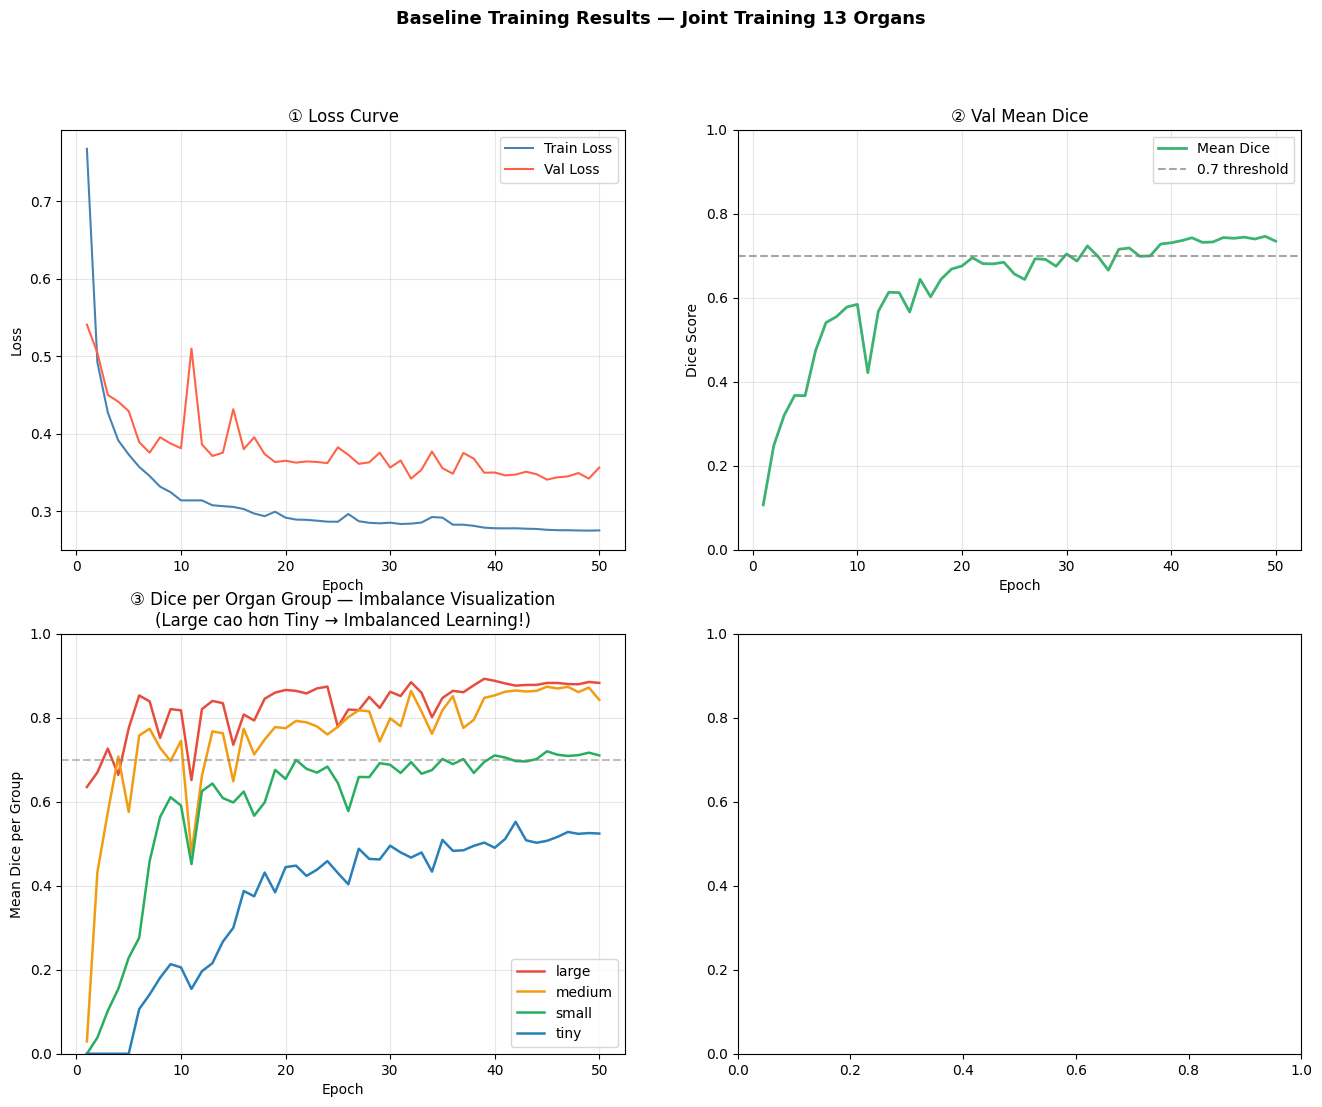

In [ ]:
# ============================================================
# Training Curves
# ============================================================
history = trainer.history
epochs  = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Baseline Training Results — Joint Training 13 Organs', fontsize=13, fontweight='bold')

# ① Loss curve
axes[0][0].plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
axes[0][0].plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
axes[0][0].set_xlabel("Epoch"); axes[0][0].set_ylabel("Loss")
axes[0][0].set_title("① Loss Curve")
axes[0][0].legend(); axes[0][0].grid(alpha=0.3)

# ② Mean Dice curve
axes[0][1].plot(epochs, history["val_dice"], color="mediumseagreen", linewidth=2, label="Mean Dice")+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
axes[0][1].axhline(0.7, color='gray', linestyle='--', alpha=0.7, label="0.7 threshold")
axes[0][1].set_xlabel("Epoch"); axes[0][1].set_ylabel("Dice Score")
axes[0][1].set_title("② Val Mean Dice")
axes[0][1].set_ylim(0, 1); axes[0][1].legend(); axes[0][1].grid(alpha=0.3)

# ③ Dice per GROUP curve — thấy rõ imbalance
group_colors = {'large': '#e74c3c', 'medium': '#f39c12',
                'small': '#27ae60', 'tiny'  : '#2980b9'}
for group, color in group_colors.items():
    group_dices = [h.get(group, 0.0) for h in history["dice_per_group"]]
    axes[1][0].plot(epochs, group_dices, label=f"{group}", color=color, linewidth=1.8)

axes[1][0].axhline(0.7, color='gray', linestyle='--', alpha=0.5)
axes[1][0].set_xlabel("Epoch"); axes[1][0].set_ylabel("Mean Dice per Group")
axes[1][0].set_title("③ Dice per Organ Group — Imbalance Visualization\n"
                     "(Large cao hơn Tiny → Imbalanced Learning!)")
axes[1][0].set_ylim(0, 1); axes[1][0].legend(); axes[1][0].grid(alpha=0.3)

# ④ Final Dice per organ (bar chart tại epoch cuối)
last_dice = history["dice_per_organ"][-1]
organ_ids = ALL_13_ORGANS
dice_vals = [last_dice.get(o) or 0.0 for o in organ_ids]
organ_short = [ORGAN_NAMES[o].split('(')[0].strip()[:10] for o in organ_ids]
bar_colors  = [color_map.get(o, '#7f8c8d') for o in organ_ids]

bars = axes[1][1].bar(organ_short, dice_vals, color=bar_colors, edgecolor='white')
axes[1][1].axhline(0.7, color='gray', linestyle='--', alpha=0.7, label="0.7 threshold")
axes[1][1].set_xlabel("Organ")
axes[1][1].set_ylabel("Dice Score")
axes[1][1].set_title("④ Final Dice per Organ\n"
                     "(Organ nhỏ → Dice thấp → Bằng chứng Imbalance)")
axes[1][1].set_ylim(0, 1)
axes[1][1].tick_params(axis='x', rotation=45)
axes[1][1].legend()

# Thêm giá trị lên bar
for bar, val in zip(bars, dice_vals):
    if val > 0.05:
        axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
fig_path = f"{LOG_DIR}/baseline_training_results.png"
plt.savefig(fig_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fig_path}")

In [ ]:
# ============================================================
# ✅ BASELINE REPORT — Bảng kết quả cuối cùng
# ============================================================
print("\n" + "="*70)
print("  BASELINE JOINT TRAINING — KẾT QUẢ CUỐI CÙNG")
print("  Dùng làm chuẩn đối sánh (Baseline) cho CIL experiments")
print("="*70)

# Chạy validation lần cuối trên val set
model.eval()
_, final_dice = trainer.validate(val_loader)

mean_dice, group_means = print_dice_table(final_dice)

# Tính Imbalance Gap (chỉ số quan trọng)
large_dice = group_means.get('large', 0.0)
tiny_dice  = group_means.get('tiny',  0.0)
imbalance_gap = large_dice - tiny_dice

print(f"\n  📌 IMBALANCE METRICS:")
print(f"     Mean Dice (large organs): {large_dice:.4f}")
print(f"     Mean Dice (tiny organs) : {tiny_dice:.4f}")
print(f"     Imbalance Gap           : {imbalance_gap:.4f}")
print(f"     → Gap lớn = Imbalanced Learning rõ ràng")
print(f"     → Mục tiêu CIL phase tiếp theo: giảm Gap này")

# Lưu baseline results
baseline_results = {
    "experiment"       : "Baseline Joint Training",
    "n_epochs"         : TRAIN_CFG["n_epochs"],
    "best_val_dice"    : round(trainer.best_val_dice, 4),
    "final_mean_dice"  : round(mean_dice, 4),
    "imbalance_gap"    : round(imbalance_gap, 4),
    "dice_per_group"   : {k: round(v, 4) for k, v in group_means.items()},
    "dice_per_organ"   : {
        ORGAN_NAMES[o]: round(final_dice[o], 4)
        for o in ALL_13_ORGANS
        if not np.isnan(final_dice.get(o, float('nan')))
    }
}

results_path = f"{LOG_DIR}/baseline_final_results.json"
with open(results_path, 'w') as f:
    json.dump(baseline_results, f, indent=2, ensure_ascii=False)
print(f"\n✅ Baseline results saved: {results_path}")
print("   File này sẽ được dùng để so sánh với CIL experiments sau này.")


  BASELINE JOINT TRAINING — KẾT QUẢ CUỐI CÙNG
  Dùng làm chuẩn đối sánh (Baseline) cho CIL experiments

  Evaluation — Dice per organ:
  Nhóm      Organ                               Dice  Status
  --------------------------------------------------------------
  large     Liver (Gan)                       0.9492  Good
  large     Stomach (Dạ dày)                  0.8166  Good
  medium    Spleen (Lách)                     0.7819  Good
  medium    Right Kidney (Thận P)             0.8606  Good
  medium    Left Kidney (Thận T)              0.8660  Good
  medium    Aorta (ĐM chủ)                    0.8615  Good
  small     Gallbladder (Túi mật)             0.7083  Good
  small     IVC (TM chủ dưới)                 0.7625  Good
  small     Portal Vein (TM cửa)              0.6928  Fair
  small     Pancreas (Tụy)                    0.6776  Fair
  tiny      Esophagus (Thực quản)             0.6892  Fair
  tiny      Right Adrenal (TTT P)             0.4658  ⚠️ Poor
  tiny      Left Adrenal (T

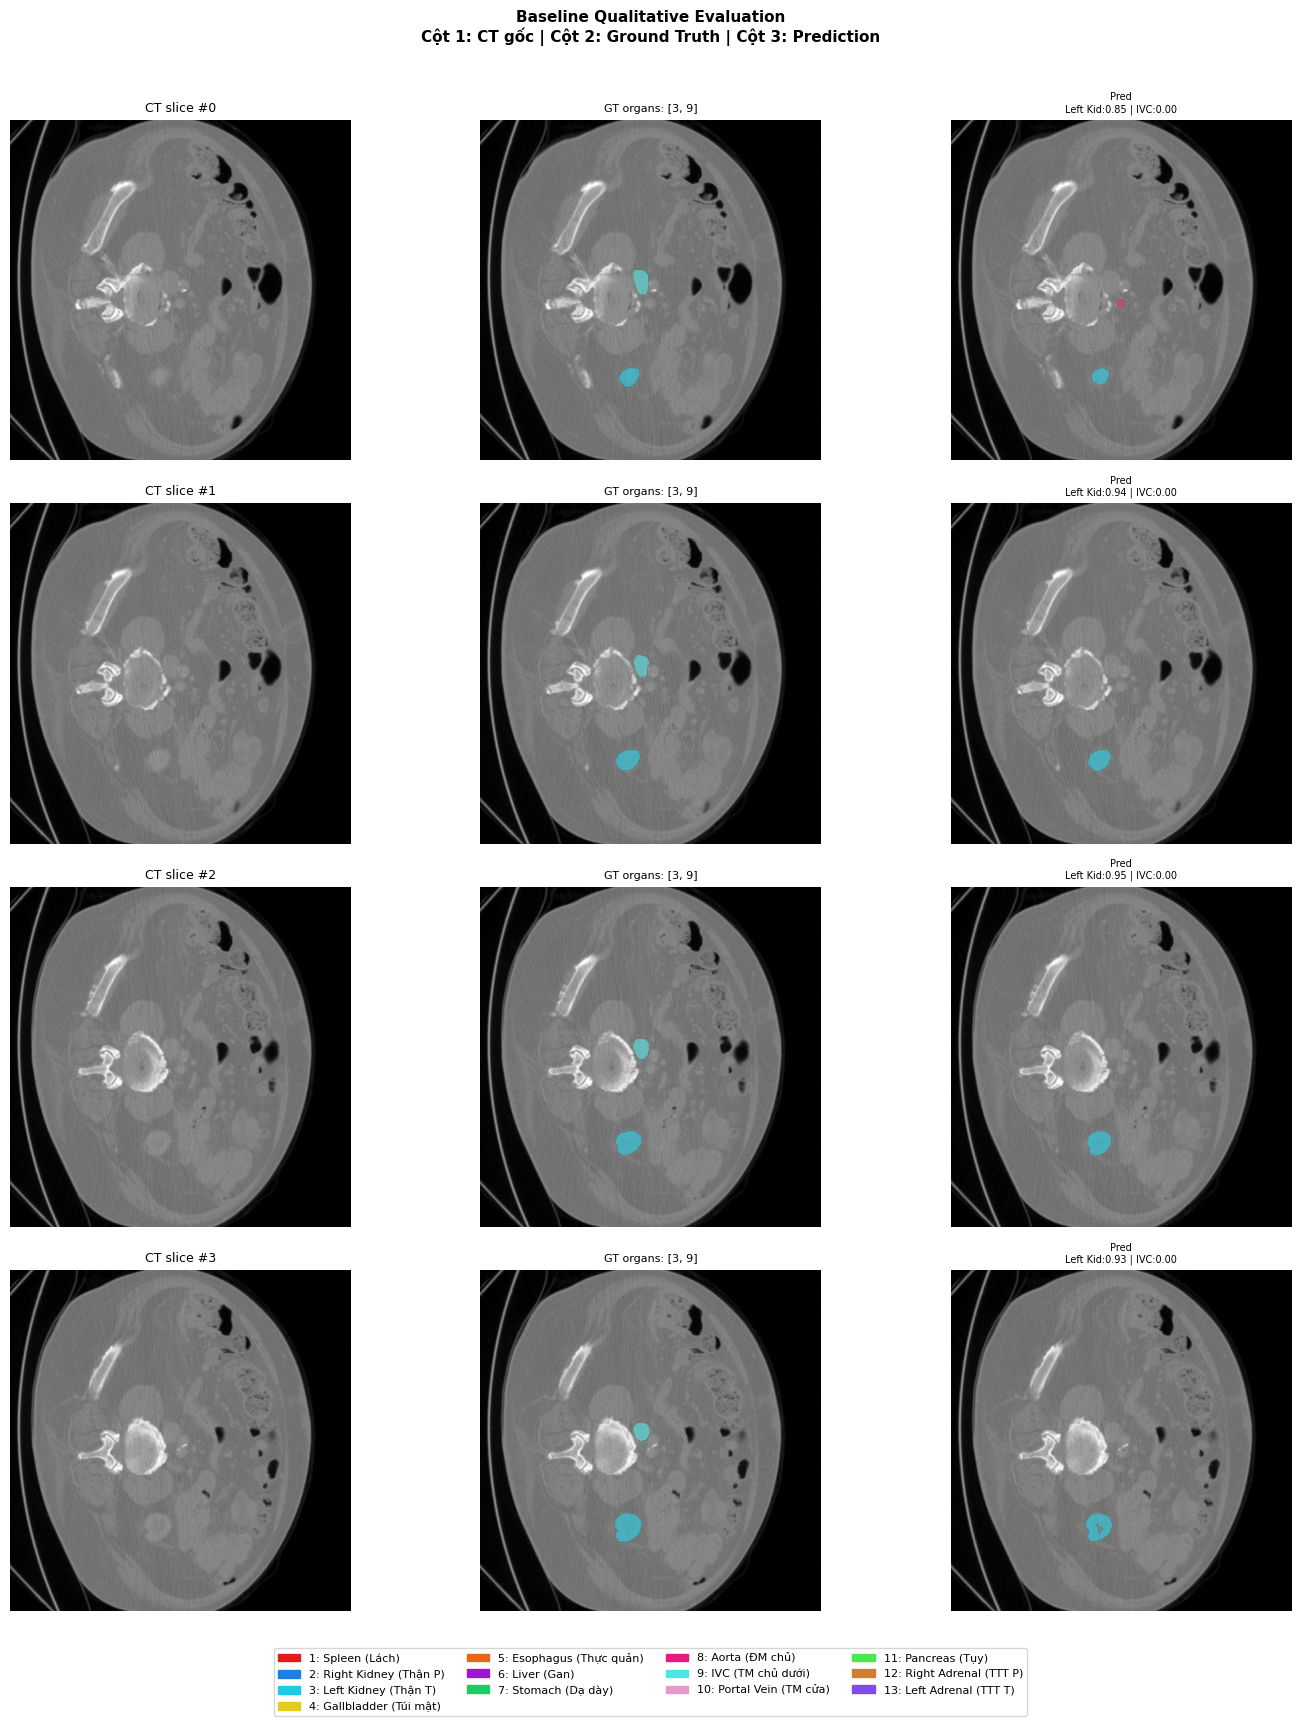

✅ Saved: /content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/baseline_qualitative.png


In [ ]:
# ============================================================
# Qualitative Evaluation — Xem prediction trực quan
# ============================================================
model.eval()

ct_batch, mask_batch = next(iter(val_loader))
ct_batch   = ct_batch.to(DEVICE)
mask_batch = mask_batch.to(DEVICE)

with torch.no_grad():
    logits = model(ct_batch)                              # (B, 14, H, W)
    preds  = torch.argmax(logits, dim=1).cpu().numpy()    # (B, H, W)

ct_np   = ct_batch.cpu().numpy()[:, 0]    # (B, H, W)
mask_np = mask_batch.cpu().numpy()        # (B, H, W)

n_show = min(4, ct_np.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show))
fig.suptitle(
    'Baseline Qualitative Evaluation\n'
    'Cột 1: CT gốc | Cột 2: Ground Truth | Cột 3: Prediction',
    fontsize=11, fontweight='bold', y=1.01
)

if n_show == 1:
    axes = [axes]

for i in range(n_show):
    ct_i   = ct_np[i]
    gt_i   = mask_np[i].astype(float)
    pred_i = preds[i].astype(float)

    axes[i][0].imshow(ct_i, cmap='gray', origin='upper')
    axes[i][0].set_title(f'CT slice #{i}', fontsize=9)
    axes[i][0].axis('off')

    # Ground Truth — tất cả 13 organs
    axes[i][1].imshow(ct_i, cmap='gray', origin='upper')
    gt_masked = np.ma.masked_where(gt_i == 0, gt_i)
    axes[i][1].imshow(gt_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')
    gt_organs = sorted([int(o) for o in np.unique(gt_i) if o > 0])
    axes[i][1].set_title(f'GT organs: {gt_organs}', fontsize=8)
    axes[i][1].axis('off')

    # Prediction
    axes[i][2].imshow(ct_i, cmap='gray', origin='upper')
    pred_masked = np.ma.masked_where(pred_i == 0, pred_i)
    axes[i][2].imshow(pred_masked, cmap=ORGAN_CMAP, vmin=0, vmax=13, alpha=0.7, origin='upper')

    # Tính Dice cho slice này
    pred_t   = torch.tensor(preds[i:i+1])
    gt_t     = torch.tensor(mask_np[i:i+1].astype(np.int64))
    slice_dice = compute_dice_all_organs(logits[i:i+1].cpu(), gt_t)

    # Chỉ hiển thị organs có mặt
    present_organs = gt_organs  # organs có trong ground truth
    dice_str = " | ".join([
        f"{ORGAN_NAMES[o].split('(')[0].strip()[:8]}:{slice_dice[o]:.2f}"
        for o in ALL_13_ORGANS
        if o in gt_organs and not np.isnan(slice_dice.get(o, float('nan')))
    ])
    axes[i][2].set_title(f'Pred\n{dice_str}', fontsize=7)
    axes[i][2].axis('off')

# Legend
patches = [mpatches.Patch(color=ORGAN_COLORS[o][:3], label=f"{o}: {ORGAN_NAMES[o]}")
           for o in ALL_13_ORGANS]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
vis_path = f"{LOG_DIR}/baseline_qualitative.png"
plt.savefig(vis_path, dpi=100, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {vis_path}")